### Data Importation and cleaning


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

df = pd.read_csv("C:\\Users\\HomePC\\Downloads\\TB_outcomes_age_sex_2026-07-03.csv",
             index_col='country', 
            names=['country','iso2','iso3','iso_numceric','WHO_region','year','cohort_type',
                     'age_group','sex','total_patients_cohort','success','failure','deaths',
                     'lost_to_follow_up','not_evaluated','success_rate'])

df = df.drop(labels='country', axis=0)

sex_full = []
for data in df['sex']:
    if data == 'f':
        sex_full.append('Female')
    elif data == 'm':
        sex_full.append('Male')
    elif data == 'a':
        sex_full.append('All sexes')

df['sex'] = sex_full


ages= []

for age in df['age_group']:
    if age == 'a':
        ages.append('All ages')
    else:
        ages.append(age)


df['age_group'] = ages


df['total_patients_cohort'] = pd.to_numeric(df['total_patients_cohort'], errors='coerce')
df['success'] = pd.to_numeric(df['success'], errors='coerce')
df['failure'] = pd.to_numeric(df['failure'], errors='coerce')
df['deaths'] = pd.to_numeric(df['deaths'], errors='coerce')
df['lost_to_follow_up'] = pd.to_numeric(df['lost_to_follow_up'], errors='coerce')
df['not_evaluated'] = pd.to_numeric(df['total_patients_cohort'], errors='coerce')
df['success_rate'] = pd.to_numeric(df['success_rate'], errors='coerce')
df['year'] = pd.to_numeric(df['year'], errors='coerce')

### Exploration analysis of the Success Rate distribution across countries and chart using Plotly Library

In [2]:
tb_region = df.groupby(['iso3'])['success_rate'].median()
tb_region = tb_region.reset_index()
tb_region

,iso3,success_rate
0,ABW,NaN
1,AFG,96.0
2,ALB,100.0
3,AND,NaN
4,ARE,77.5
...,...,...
190,WLF,NaN
191,WSM,100.0
192,ZAF,81.0
193,ZMB,92.5


In [4]:
fig = px.choropleth(
    tb_region,
    locations='iso3',
    color='success_rate',
    title='Countries Success Rates(%)'

)

fig.show()

### Number of Regional TB patients who did not complete their treatment

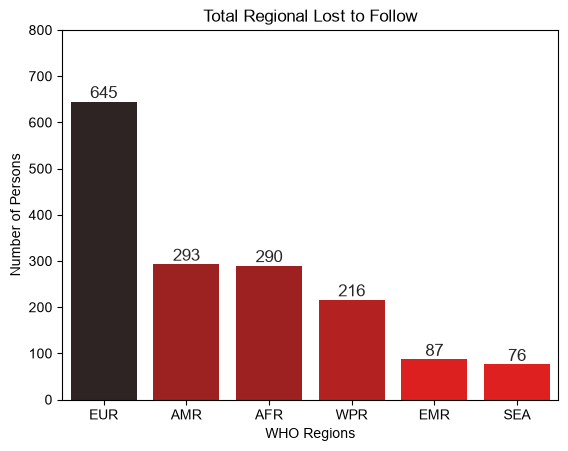

In [5]:


tb_lost = df.groupby('WHO_region')['lost_to_follow_up'].size().sort_values(ascending=False).reset_index()


n_lost = sns.barplot(data=tb_lost, 
            x='WHO_region', 
            y='lost_to_follow_up',
            hue='lost_to_follow_up',
            palette='dark:r_r',
            legend = False
            )

sns.set_theme(style='ticks')

plt.ylim(0,800)
plt.xlabel('WHO Regions')
plt.ylabel('Number of Persons')
plt.title('Total Regional Lost to Follow')

for label in n_lost.containers:
    n_lost.bar_label(label, fmt='%.0f')

plt.show()



### Exploration of the relationship btw incomplete treatments and Success Rate by gender

In [6]:
tb_gender = df[df['sex']!='All sexes'].pivot_table(
    index='sex',
    values='lost_to_follow_up',
    aggfunc='sum'
    )
tb_gender

,lost_to_follow_up
sex,
Female,318844.0
Male,628190.0


In [9]:
tb_gender2 = df[df['sex']!='All sexes'].pivot_table(
    index='sex',
    values='success_rate',
    aggfunc='median'
    )
tb_gender2

,success_rate
sex,
Female,87.0
Male,85.0


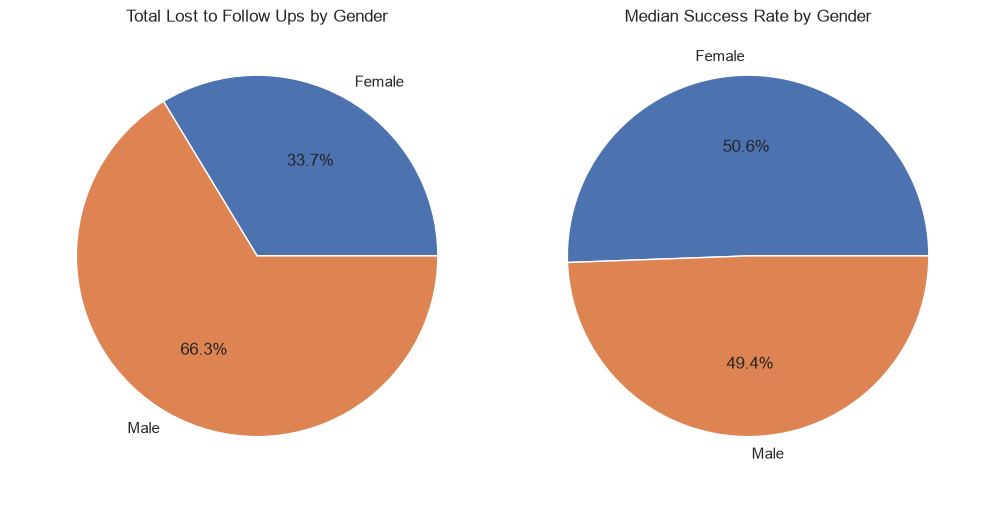

In [10]:
fig, ax = plt.subplots(1,2)
tb_gender_plot= tb_gender.plot(kind='pie', autopct='%.1f%%', y='lost_to_follow_up',ax=ax[0], figsize=(10,6), legend=False)
ax[0].set_title('Total Lost to Follow Ups by Gender')
ax[0].set_xlabel(' ')
ax[0].set_ylabel(' ')




tb_gender2_plot = tb_gender2.plot(kind='pie',y='success_rate', autopct='%.1f%%', ax=ax[1], legend=False, figsize=(10,6))
ax[1].set_title('Median Success Rate by Gender')
ax[1].set_ylabel(' ')
ax[1].set_xlabel(' ')




fig.tight_layout()